### HideToSee

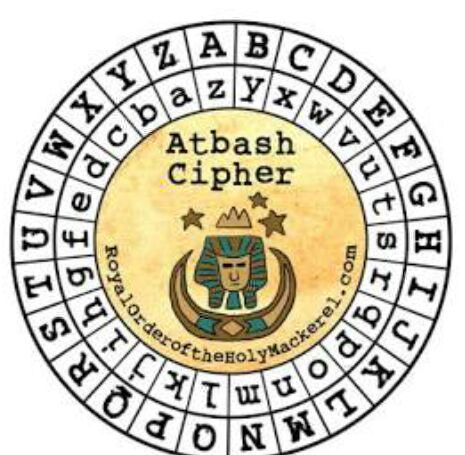

In [1]:
from IPython.display import Image, display
display(Image(filename='atbash.jpg'))

the output: 'encrypted.txt' of this command: steghide extract -sf atbash.jpg. Is the one being used in this excercise

In [2]:
with open("encrypted_atbash.txt", "r", encoding="utf-8") as f:
    encrypted_atbash = f.read()

In [3]:
def atbash_cipher(plaintext):
    vocab = 'abcdefghijklmnopqrstuvwxyz'
    reversed_vocab = vocab[::-1]
    result = []

    for char in plaintext:
        if char.lower() in vocab:
            idx = vocab.index(char.lower())
            new_char = reversed_vocab[idx]
            result.append(new_char.upper() if char.isupper() else new_char)
        else:
            result.append(char)
            
    return "".join(result)

In [4]:
hidetosee_output = atbash_cipher(encrypted_atbash)
print(hidetosee_output)

picoCTF{atbash_crack_8a0feddc}



### Rotation


In [5]:
with open("encrypted_rotation.txt", "r", encoding="utf-8") as f:
    encrypted_rotation = f.read()

Rotation cipher is a key fixed #8 version of caesar cipher. So we keep the logic

In [6]:
def caesar_cipher(cybertext, key):
    vocab = 'abcdefghijklmnopqrstuvwxyz'
    plaintext_list = [] 
    
    for char in cybertext:
        char_lower = char.lower()
        
        if char_lower in vocab:
            index = (vocab.index(char_lower) - key) % len(vocab)
            new_char = vocab[index]
            
            plaintext_list.append(new_char.upper() if char.isupper() else new_char)
        else:
            plaintext_list.append(char)
            
    return "".join(plaintext_list)

In [7]:
rotation_output = caesar_cipher(encrypted_rotation, 8)
print(rotation_output)

picoCTF{r0tat1on_d3crypt3d_429af00f}



### Substitution2

In [9]:
with open("message.txt", "r", encoding="utf-8") as f:
    message = f.read()

In [37]:
#substitution2
import re
from collections import Counter

def solve_substitution_cipher(ciphertext, known_mappings):
    """
    Solve a substitution cipher using frequency analysis and known mappings
    """
    # Convert to lowercase for analysis (but preserve case for flag)
    cipher_lower = ciphertext.lower()
    
    # Initial mapping from known plaintext
    mapping = {}
    reverse_mapping = {}
    
    # Add known mappings from "sxzqZNV" = "picoCTF"
    # Note: We need to handle case carefully
    known_pairs = [
        ('s', 'p'), ('x', 'i'), ('z', 'c'), ('q', 'o'),
        ('Z', 'C'), ('N', 'T'), ('V', 'F')
    ]
    
    for cipher_char, plain_char in known_pairs:
        mapping[cipher_char] = plain_char
        reverse_mapping[plain_char.lower()] = cipher_char.lower()
    
    # English letter frequencies (most common to least)
    english_freq = ['e', 't', 'a', 'o', 'i', 'n', 's', 'h', 'r', 'd', 
                    'l', 'c', 'u', 'm', 'w', 'f', 'g', 'y', 'p', 'b',
                    'v', 'k', 'j', 'x', 'q', 'z']
    
    # Count frequencies in ciphertext (excluding already mapped letters)
    cipher_counts = Counter(c for c in cipher_lower if c.isalpha() and c not in mapping)
    
    # Sort cipher letters by frequency
    sorted_cipher = [item[0] for item in cipher_counts.most_common()]
    
    # Create a list of unused English letters
    used_plains = [v.lower() for v in mapping.values() if isinstance(v, str)]
    available_plains = [c for c in english_freq if c not in used_plains]
    
    # Tentatively map remaining letters by frequency
    temp_mapping = mapping.copy()
    for i, cipher_char in enumerate(sorted_cipher):
        if cipher_char not in temp_mapping and i < len(available_plains):
            temp_mapping[cipher_char] = available_plains[i]
    
    # Function to decode with current mapping
    def decode(text, mapping_dict):
        result = []
        for char in text:
            if char.isalpha():
                if char.isupper():
                    # Try uppercase mapping, fallback to lowercase mapping then uppercase
                    if char in mapping_dict:
                        result.append(mapping_dict[char])
                    elif char.lower() in mapping_dict:
                        result.append(mapping_dict[char.lower()].upper())
                    else:
                        result.append('_')
                else:
                    if char in mapping_dict:
                        result.append(mapping_dict[char])
                    else:
                        result.append('_')
            else:
                result.append(char)
        return ''.join(result)
    
    # Decode with current mapping
    decoded = decode(ciphertext, temp_mapping)
    
    # Extract the flag part (between { and })
    flag_match = re.search(r'\{([^}]+)\}', decoded)
    if flag_match:
        inner_flag = flag_match.group(1)
        # The flag should be in the format picoCTF{...}
        full_flag = f"picoCTF{{{inner_flag}}}"
        return full_flag, decoded
    
    return decoded, temp_mapping


# Solve
flag, full_decoded = solve_substitution_cipher(message, {})

print("Predicted flag:", flag)
print("\nFull decoded text (first 500 chars):")
print(full_decoded)

Predicted flag: picoCTF{N6R4W_4N41V515_15_73G10U5_8E1KF808}

Full decoded text (first 500 chars):
adereeqisaseberhloaderjellesahklisdegdiydscdoolcowpuaersecuriavcowpeaiaionsincluginycvkerpharioahnguscvkercdhllenyeadesecowpeaiaionsmocuspriwhrilvonsvsaewshgwinisarhaionmunghwenahlsjdicdhrebervusemulhngwhrxeahklesxillsdojeberjekeliebeadeproperpurposeomhdiydscdoolcowpuaersecuriavcowpeaiaionisnoaonlvaoaehcdbhluhklesxillskuahlsoaoyeasaugenasinaeresaeginhngeqciaeghkouacowpuaersciencegemensibecowpeaiaionshreomaenlhkorioushmmhirshngcowegojnaorunninycdecxlisashngeqecuainyconmiyscripasommenseonadeoaderdhngisdehbilvmocusegoneqplorhaionhngiwprobishaionhngomaendhselewenasomplhvjekeliebehcowpeaiaionaoucdinyonadeommensibeelewenasomcowpuaersecuriavisaderemorehkeaaerbediclemoraecdebhnyeliswaosaugenasinhwerichndiydscdoolsmuraderjekeliebeadhahnungersahnginyomommensibeaecdnizuesisessenaihlmorwounainyhnemmecaibegemensehngadhaadeaoolshngconmiyurhaionmocusencounaeregingemensibecowpeaiaionsgoesnoalehgsaugenasao

### Vigenere

In [30]:
with open("cipher.txt", "r", encoding="utf-8") as f:
    cipher = f.read()

In [31]:
def vigenere_decrypt(ciphertext, keyword):
    vocab = 'abcdefghijklmnopqrstuvwxyz'
    result = []
    keyword = keyword.lower() 
    key_index = 0  
    
    for char in ciphertext:
        char_lower = char.lower()
        
        if char_lower in vocab:

            char_pos = vocab.index(char_lower)
            key_char = keyword[key_index % len(keyword)]
            key_pos = vocab.index(key_char)
            
            decrypted_pos = (char_pos - key_pos) % len(vocab)
            new_char = vocab[decrypted_pos]
            
            result.append(new_char.upper() if char.isupper() else new_char)
            
            key_index += 1
        else:
            result.append(char)
    
    return "".join(result)

In [32]:
vigenere_output = vigenere_decrypt(cipher, "CYLAB")
print(vigenere_output)

picoCTF{D0NT_US3_V1G3N3R3_C1PH3R_2951a89h}

